In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from xgboost import XGBClassifier

In [2]:
n = None
data_dir = Path("stgnn/data/mimic_processed")
if not data_dir.exists():
    data_dir = Path("data/mimic_processed")

combined_path = data_dir / "ehr_combined.csv"
flat_path = data_dir / "ehr_combined_flat.csv"

if not combined_path.exists():
    raise FileNotFoundError(f"Missing {combined_path}. Run stgnn/preprocess_ehr.py first.")
if not flat_path.exists():
    raise FileNotFoundError(f"Missing {flat_path}. Generate it with: python stgnn/flatten_data.py")

meta = pd.read_csv(combined_path, usecols=["hadm_id", "subject_id", "splits"]).drop_duplicates().set_index("hadm_id")
flat_df = pd.read_csv(flat_path, index_col="hadm_id", nrows=n)
df = meta.join(flat_df, how="right")

splits = df["splits"]
subject_ids = pd.to_numeric(df["subject_id"], errors="coerce").astype("Int64")
df = df.drop(columns=["splits", "subject_id"]).astype(np.float32)

train_df = df[splits == "train"]
train_x, train_y = train_df.drop(columns="readmitted"), train_df.readmitted.values

val_df = df[splits == "val"]
val_x, val_y = val_df.drop(columns="readmitted"), val_df.readmitted.values

note_eval_relative = Path("results/mimiciv/note_only/test_eval/hospital_readmission")
note_eval_candidates = [
    note_eval_relative,
    Path("../ehr-text-multi-modal") / note_eval_relative,
    Path("/Users/edward/repo/ehr-text-multi-modal") / note_eval_relative,
]
note_eval_dir = next((path for path in note_eval_candidates if path.exists()), note_eval_candidates[0])
subject_file = note_eval_dir / "note_only_test_subject_ids.csv"
hadm_subject_file = note_eval_dir / "note_only_test_hadm_subject_ids.csv"
if not subject_file.exists() or not hadm_subject_file.exists():
    raise FileNotFoundError(
        "Missing note-only test-set CSVs. Checked: "
        + ", ".join(str(path) for path in note_eval_candidates)
    )

note_subject_df = pd.read_csv(subject_file)
note_hadm_subject_df = pd.read_csv(hadm_subject_file)

subject_col = "subject_id" if "subject_id" in note_subject_df.columns else note_subject_df.columns[0]
hadm_col = "hadm_id" if "hadm_id" in note_hadm_subject_df.columns else note_hadm_subject_df.columns[0]

note_test_subject_ids = set(pd.to_numeric(note_subject_df[subject_col], errors="coerce").dropna().astype(int))
note_test_hadm_ids = set(pd.to_numeric(note_hadm_subject_df[hadm_col], errors="coerce").dropna().astype(int))

full_test_mask = subject_ids.isin(note_test_subject_ids)
note_only_test_mask = df.index.astype("int64").isin(note_test_hadm_ids)

test_df = df[note_only_test_mask]
test_x, test_y = test_df.drop(columns="readmitted"), test_df.readmitted.values

print({
    "full_test_admissions": int(full_test_mask.sum()),
    "note_only_test_admissions": int(note_only_test_mask.sum()),
    "unique_test_subject_ids": int(subject_ids[full_test_mask].nunique()),
})

{'full_test_admissions': 38150, 'note_only_test_admissions': 32728, 'unique_test_subject_ids': 14239}


In [3]:
def bootstrap_auc_ci(y_true, y_prob, n_bootstrap=1000, alpha=0.95, seed=0):
    rng = np.random.default_rng(seed)
    aucs = []
    for _ in range(n_bootstrap):
        idx = rng.choice(len(y_true), len(y_true), replace=True)
        aucs.append(roc_auc_score(y_true[idx], y_prob[idx]))
    low = np.percentile(aucs, (1 - alpha) / 2 * 100)
    high = np.percentile(aucs, (1 + alpha) / 2 * 100)
    return low, high


models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, n_jobs=-1),
    "XGBoost": XGBClassifier(
        n_estimators=1000,
        learning_rate=0.03,
        max_depth=3,
        min_child_weight=1,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="binary:logistic",
        eval_metric="auc",
        random_state=0,
    ),
}

results = {}
xgb_eval_results = None

for model_name, model in models.items():
    if model_name == "XGBoost":
        model.fit(train_x, train_y, eval_set=[(val_x, val_y)], verbose=False)
        xgb_eval_results = model.evals_result()
    else:
        model.fit(train_x, train_y)

    test_pred = model.predict_proba(test_x)[:, 1]
    test_auc = roc_auc_score(test_y, test_pred)
    ci_low, ci_high = bootstrap_auc_ci(test_y, test_pred)

    results[model_name] = {
        "test_auc": test_auc,
        "ci_low": ci_low,
        "ci_high": ci_high,
    }

results_df = pd.DataFrame(results).T
metrics_path = note_eval_dir / "xgboost_lr_test_metrics.csv"
results_df.to_csv(metrics_path)
print(f"Saved: {metrics_path}")
results_df

/Users/edward/repo/readmit-stgnn/.venv/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Saved: ../ehr-text-multi-modal/results/mimiciv/note_only/test_eval/hospital_readmission/xgboost_lr_test_metrics.csv


,test_auc,ci_low,ci_high
Logistic Regression,0.652562,0.644695,0.660240
XGBoost,0.664254,0.656287,0.671541


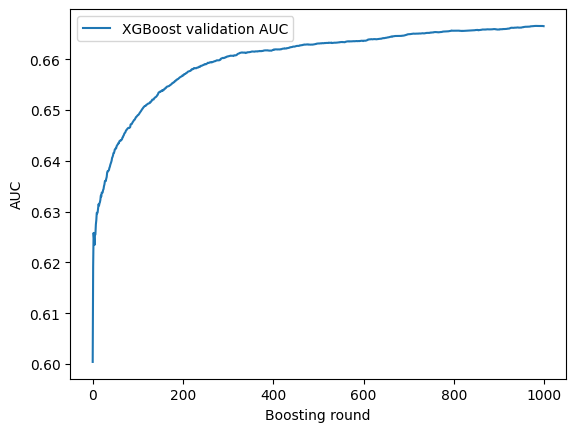

Saved: ../ehr-text-multi-modal/results/mimiciv/note_only/test_eval/hospital_readmission/xgboost_lr_test_metrics_display.csv


,display
Logistic Regression,0.653 (95% CI 0.645-0.660)
XGBoost,0.664 (95% CI 0.656-0.672)


In [4]:
if xgb_eval_results is not None:
    epochs = len(xgb_eval_results["validation_0"]["auc"])
    x_axis = range(epochs)
    fig, ax = plt.subplots()
    ax.plot(x_axis, xgb_eval_results["validation_0"]["auc"], label="XGBoost validation AUC")
    ax.set_xlabel("Boosting round")
    ax.set_ylabel("AUC")
    ax.legend()
    plt.show()

summary = pd.DataFrame(results).T
summary["display"] = summary.apply(
    lambda r: f"{r['test_auc']:.3f} (95% CI {r['ci_low']:.3f}-{r['ci_high']:.3f})", axis=1
)

summary_display = summary[["display"]]
summary_path = note_eval_dir / "xgboost_lr_test_metrics_display.csv"
summary_display.to_csv(summary_path)
print(f"Saved: {summary_path}")
summary_display